In [1]:
import numpy as np
from joblib import Parallel, delayed
from ping_monitor import PingMonitor
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import scipy as sp

In [2]:
def ping(domain):
    p = PingMonitor(target=domain, duration=4 * 3600)

    p.start()
    success = p.wait(timeout=7200 + 100)
    if not success:
        p.stop()
    p.save_times_only()
    return True

In [3]:
new_ping = False

In [4]:
domains_moscow = [
    'cs.msu.ru', 
    'ras.ru', 
    'mai.ru', 
    'hse.ru', 
    'mipt.ru', 
    'skoltech.ru', 
    'bmstu.ru', 
    'gubkin.ru', 
    'ranepa.ru',
    'misis.ru',
    'sechenov.ru', 
    'rguk.ru',
    'stankin.ru',
    'mgimo.ru',
    'miit.ru',
    'fa.ru',
    'mtuci.ru',
    'mosgu.ru',
    'linguanet.ru',
    'msal.ru',
    'madi.ru',
    'rsuh.ru',
    'mfua.ru'
]

In [5]:
domains = [
    'cs.msu.ru', 
    '8.8.8.8', 
    'arxiv.org',  
    'www.com.ar',
    '4.2.2.2',
    '192.0.43.10',
    'yahoo.com',
    '176.74.219.29',
    #'baidu.com',
    'aliexpress.com',
    '208.67.222.222',
    '69.162.81.155',
    'mathnet.ru',
    'yandex.ru',
    'nedlac.org.za',
    'interview.mn',
    'visitqatar.com',
    'hurriyet.com.tr',
    'mako.co.il',
    'thanhnien.vn',
    'www.uq.edu.au',
    'upeu.edu.pe',
    'www.cmu.ac.th',
    'www.l.u-tokyo.ac.jp',
    'primature.ml',
    'taiwannews.com.tw',
    'flysaa.com',
    'vietnam.travel',
    'mongol.net',
    'omanair.com',
    'golosarmenii.am',
    'kazakhstan.travel',
    'visitgreece.gr',
    'amic.ru',
    'ircity.ru',    
    'ngs24.ru',
    'vlc.ru',
    'admkrsk.ru',
    'novo-sibirsk.ru',
    'pkgo.ru',
    #'admin.tomsk.ru',
    #'altairegion22.ru',
    #'oimyakon.sakha.gov.ru',
    #'biradm.ru',
    #'kabulwebsite.com',
    #'kanostate.gov.ng',
    #'welcome2addis.com',
    #'bmc.go.th',
    #'jakarta-tourism.go.id',
    #'visitlahore.com'
]

#domains = domains_moscow

assert len(domains) == len(np.unique(domains))

print(f'количество адресов: {len(domains)}')

if new_ping:
    res = Parallel(n_jobs=len(domains))(
        delayed(ping)(domain) for domain in domains
    )

количество адресов: 39


In [6]:
# timestamp = '20260101_1851'
# timestamp = '20260103_0057'
# timestamp = '20260117_2245'
timestamp = '20260113_1901'

Xs = [
    pd.read_csv(
        f'ping_data/ping_times_{domain}_{timestamp}.log', 
        header=None, 
        comment='#'
    ).to_numpy()[:, 0] \
    for domain in domains
] 
#+ [
#     pd.read_csv(
#         f'ping_data/ping_times_{domain}_20260103_0057.log', 
#         header=None, 
#         comment='#'
#     ).to_numpy()[:, 0] \
#     for domain in domains_moscow
# ]

In [7]:
# fig, axs = plt.subplots(2, 2, figsize=(8 * (1 + np.sqrt(5)) / 2, 8))

# for k, ax in enumerate(axs.flatten()):
#     left = 5 * k
#     right = left + 5
#     for i, (X, label) in enumerate(zip(Xs[left:right], domains_moscow[left:right])):
#         ax.hist(X, density=True, bins=100, alpha=1 - i/(right - left), label=label)

#     ax.legend()
#     ax.set_yscale('log')

# plt.show()

In [8]:
Ts = np.array([np.mean(X) - np.min(X) for X in Xs])
Stds = np.array([np.std(X) for X in Xs])
Jitters = np.array([np.mean(np.abs(X - np.mean(X))) for X in Xs])

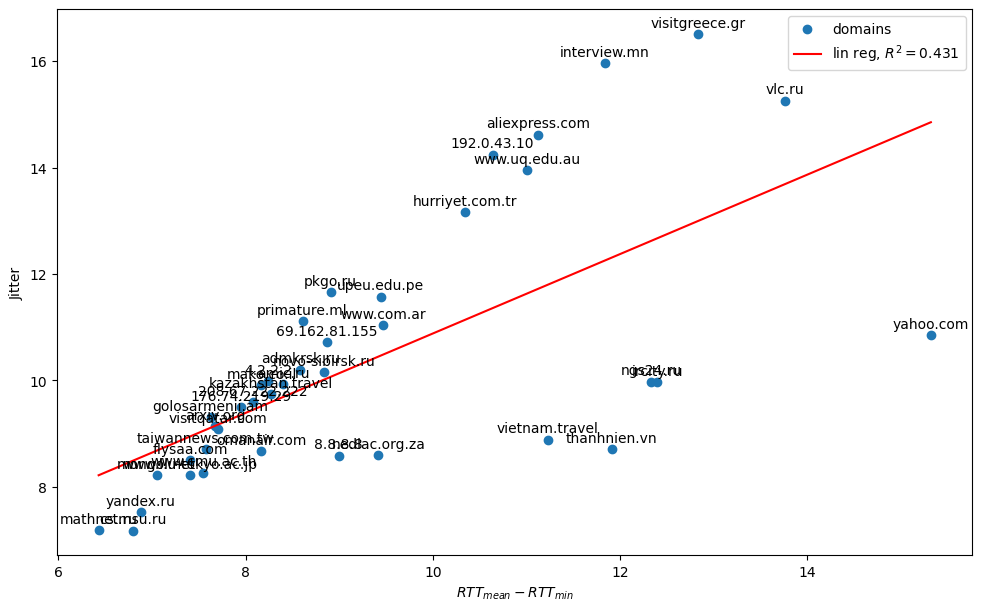

In [9]:
lr = LinearRegression()
predictors = np.hstack([Ts.reshape(-1, 1), ])
lr.fit(predictors, Jitters.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(6 * (1 + np.sqrt(5)) / 2, 6), layout='constrained')

ax.scatter(Ts, Jitters, label='domains')

for T, Jitter, domain in zip(Ts, Jitters, domains):
    ax.annotate(
        domain, 
        (T, Jitter), 
        textcoords="offset points",
        xytext=(0, 5), 
        ha='center'
    ) 

idx_sorted = np.argsort(Ts)

ax.plot(
    Ts[idx_sorted], lr.predict(predictors[idx_sorted]), color='red', 
    label=f"lin reg, $R^2 = {lr.score(predictors, Jitters.reshape(-1, 1)):.3f}$"
)

ax.legend()

ax.set_xlabel('$RTT_{mean} - RTT_{min}$')
ax.set_ylabel('Jitter')

plt.show()

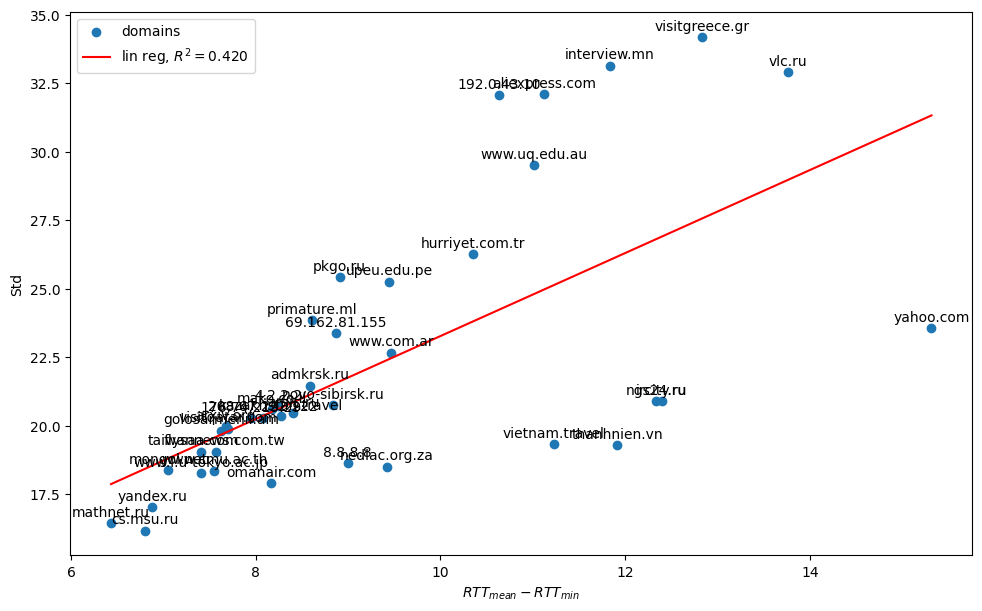

In [10]:
lr = LinearRegression()
predictors = np.hstack([Ts.reshape(-1, 1), ])

lr.fit(predictors, Stds.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(6 * (1 + np.sqrt(5)) / 2, 6), layout='constrained')

ax.scatter(Ts, Stds, label='domains')

for T, Std, domain in zip(Ts, Stds, domains):
    ax.annotate(
        domain, 
        (T, Std), 
        textcoords="offset points",
        xytext=(0, 5), 
        ha='center'
    ) 

idx_sorted = np.argsort(Ts)

ax.plot(
    Ts[idx_sorted], lr.predict(predictors[idx_sorted]), color='red', 
    label=f"lin reg, $R^2 = {lr.score(predictors, Stds.reshape(-1, 1)):.3f}$"
)

ax.legend()

ax.set_xlabel('$RTT_{mean} - RTT_{min}$')
ax.set_ylabel('Std')

plt.show()

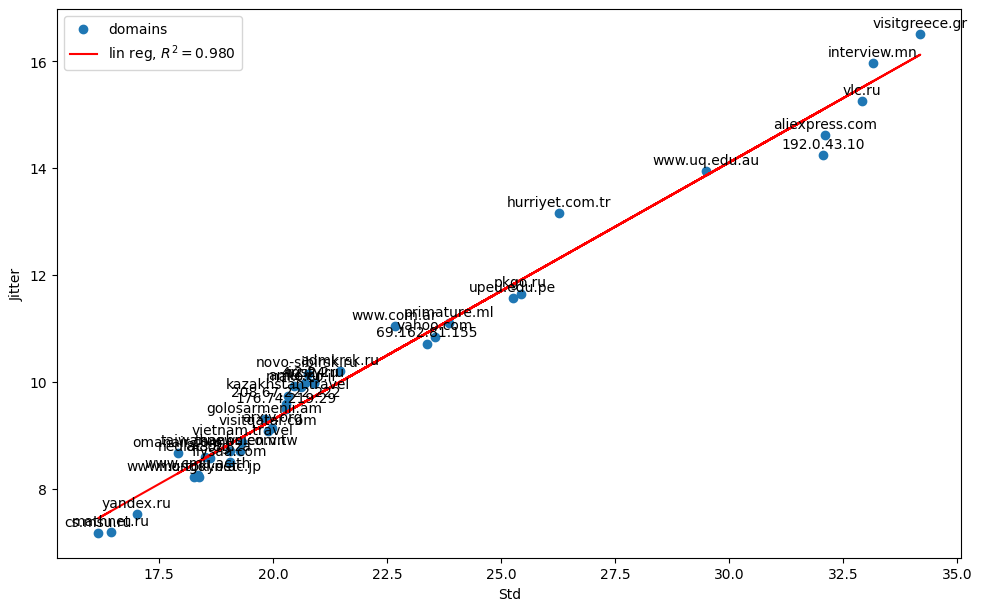

In [11]:
lr = LinearRegression()
predictors = np.hstack([Stds.reshape(-1, 1), ])

lr.fit(predictors, Jitters.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(6 * (1 + np.sqrt(5)) / 2, 6), layout='constrained')

ax.scatter(Stds, Jitters, label='domains')

for Jitter, Var, domain in zip(Jitters, Stds, domains):
    ax.annotate(
        domain, 
        (Var, Jitter), 
        textcoords="offset points",
        xytext=(0, 5), 
        ha='center'
    ) 

idx_sorted = np.argsort(Ts)

ax.plot(
    Stds[idx_sorted], lr.predict(predictors[idx_sorted]), color='red', 
    label=f"lin reg, $R^2 = {lr.score(predictors, Jitters.reshape(-1, 1)):.3f}$"
)

ax.legend()

ax.set_xlabel('Std')
ax.set_ylabel('Jitter')

plt.show()

In [12]:
def em_mixture_linear_regression(
    X,
    Y,
    n_components=2,
    max_iter=100,
    tol=1e-5,
    random_state=123
):
    rng = np.random.default_rng(seed=random_state)

    X = np.asarray(X).reshape(-1, 1)
    Y = np.asarray(Y)
    n = len(Y)

    # initialization
    log_resp = np.log(
        rng.dirichlet(
            alpha=[1] * n_components,
            size=n
        )
    )

    models = [LinearRegression() for _ in range(n_components)]
    sigmas = np.ones(n_components)
    log_pi = np.log(np.ones(n_components) / n_components)

    prev_loglik = -np.inf

    for iter in range(max_iter):

        # ---- M-step ----
        resp = np.exp(log_resp)

        for k in range(n_components):
            w = resp[:, k]
            models[k].fit(X, Y, sample_weight=w)

            residuals = Y - models[k].predict(X)
            sigmas[k] = np.sqrt(
                np.sum(w * residuals**2) / np.sum(w)
            )

            log_pi[k] = np.log(w.mean())

        # ---- E-step ----
        log_prob = np.zeros((n, n_components))

        for k in range(n_components):
            mu = models[k].predict(X)
            log_pdf = -0.5 * (
                np.log(2 * np.pi * sigmas[k]**2)
                + ((Y - mu) ** 2) / (sigmas[k]**2)
            )
            log_prob[:, k] = log_pi[k] + log_pdf

        log_norm = sp.special.logsumexp(log_prob, axis=1, keepdims=True)
        log_resp = log_prob - log_norm

        loglik = np.sum(log_norm)
        if abs(loglik - prev_loglik) < tol:
            break
        prev_loglik = loglik

    print(f'{iter} iterations done')

    labels = np.argmax(log_resp, axis=1)

    return {
        "models": models,
        "sigmas": sigmas,
        "log_pi": log_pi,
        "responsibilities": np.exp(log_resp),
        "labels": labels,
        "log_likelihood": loglik
    }


In [13]:
res = em_mixture_linear_regression(
    Ts.reshape(-1, 1),
    Jitters,
    n_components=2,
    max_iter=100,
    tol=1e-8,
    random_state=123
)

27 iterations done


In [14]:
clusters = res['labels']

domains_by_cluster = [
    [] for _ in range(max(clusters) + 1)
]

Xs_by_cluster = [
    [] for _ in range(max(clusters) + 1)
]


for i, (domain, c) in enumerate(zip(domains, clusters)):
    domains_by_cluster[c].append(domain)
    Xs_by_cluster[c].append(Xs[i])


In [15]:
for ds in domains_by_cluster:
    print(ds)

['8.8.8.8', 'yahoo.com', 'nedlac.org.za', 'thanhnien.vn', 'vietnam.travel', 'omanair.com', 'ircity.ru', 'ngs24.ru']
['cs.msu.ru', 'arxiv.org', 'www.com.ar', '4.2.2.2', '192.0.43.10', '176.74.219.29', 'aliexpress.com', '208.67.222.222', '69.162.81.155', 'mathnet.ru', 'yandex.ru', 'interview.mn', 'visitqatar.com', 'hurriyet.com.tr', 'mako.co.il', 'www.uq.edu.au', 'upeu.edu.pe', 'www.cmu.ac.th', 'www.l.u-tokyo.ac.jp', 'primature.ml', 'taiwannews.com.tw', 'flysaa.com', 'mongol.net', 'golosarmenii.am', 'kazakhstan.travel', 'visitgreece.gr', 'amic.ru', 'vlc.ru', 'admkrsk.ru', 'novo-sibirsk.ru', 'pkgo.ru']


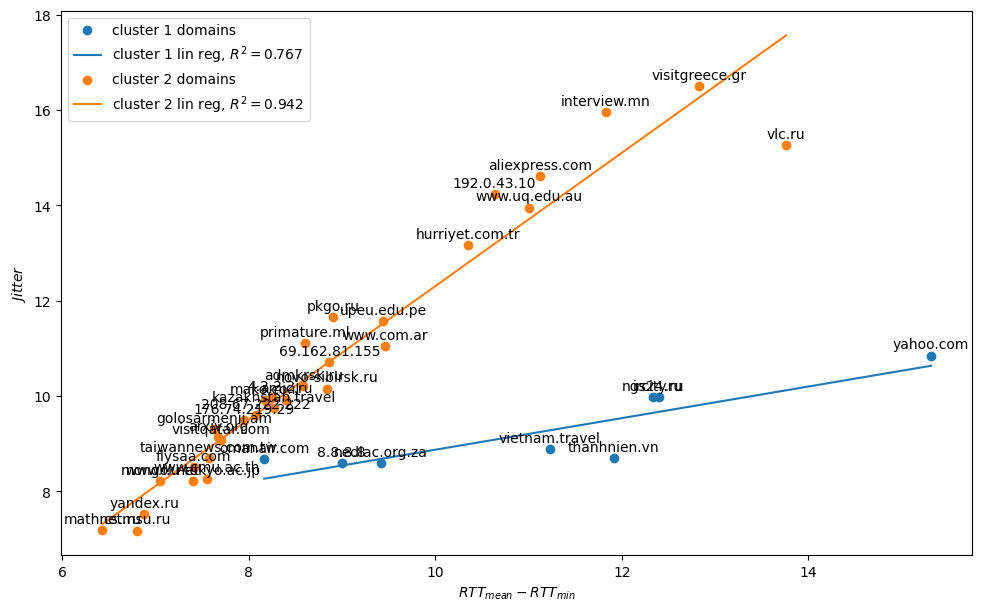

In [16]:
fig, ax = plt.subplots(figsize=(6 * (1 + np.sqrt(5)) / 2, 6), layout='constrained')

for i, (domains1, Xs1) in enumerate(zip(domains_by_cluster, Xs_by_cluster)):
    Ts1 = np.array([np.mean(X) - np.min(X) - np.std(X)/len(X) for X in Xs1])
    Jitters1 = np.array([np.mean(np.abs(X - np.mean(X))) for X in Xs1])
    
    ax.scatter(Ts1, Jitters1, label=f'cluster {i+1} domains')

    for T, Jitter, domain in zip(Ts1, Jitters1, domains1):
        ax.annotate(
            domain, 
            (T, Jitter), 
            textcoords="offset points",
            xytext=(0, 5), 
            ha='center'
        ) 

    idx_sorted = np.argsort(Ts1)

    ax.plot(
        Ts1[idx_sorted], res['models'][i].predict(Ts1.reshape(-1, 1))[idx_sorted], 
        label=f"cluster {i+1} lin reg," +\
            f" $R^2 = {res['models'][i].score(Ts1.reshape(-1, 1), Jitters1.reshape(-1, 1)):.3f}$"
    )

ax.legend()

ax.set_xlabel('$RTT_{mean} - RTT_{min}$')
ax.set_ylabel('$Jitter$')

plt.show()

In [17]:
from scipy.stats import gaussian_kde

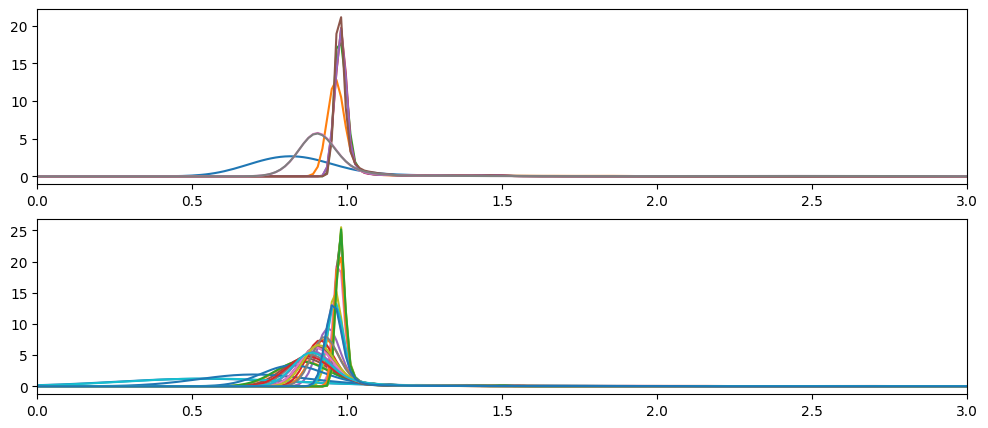

In [23]:
fig, axs = plt.subplots(2, figsize=(12, 5))

for ax, Xs in zip(axs, Xs_by_cluster):
    for X in Xs:
        data = X #- np.min(X) + np.std(X)/len(X)
        data = data / np.mean(data)
        kde = gaussian_kde(data)
        grid = np.linspace(0, 3, num=200)
        ax.plot(grid, kde.pdf(grid))
    ax.set_xlim(0, 3)
#    ax.set_ylabel('$RTT_{min}$')

#ax.set_yscale('log')
#ax.set_xscale('log')

plt.show()